An example notebook on tabular data. In this case, we are looking for an explanation into an ECG model prediction.

In [1]:
import numpy as np
import torch
import torch as tt
import torch.nn as nn

In [2]:
class Flatten(torch.nn.Module):
    def forward(self, x):
        batch_size = x.shape[0]
        return x.view(batch_size, -1)

class ArrhythmiaClassifierV2(nn.Module):
    def __init__(self, num_classes=17):
        super(ArrhythmiaClassifierV2, self).__init__()

        # --- Convolutional Block 1 with Early MaxPooling ---
        # Layer 1
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=16, padding='same')
        self.relu1 = nn.ReLU()

        # Layer 2: MaxPooling (used once, at the beginning)
        self.pool1 = nn.MaxPool1d(kernel_size=4, stride=4)
        # Output of pool1: (batch_size, 32, 3600 / 4) = (batch_size, 32, 900)

        # --- Feature Extraction Block with Strided Convolutions ---
        # Layer 3
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=12, padding='same')
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()
        # Output of conv2: (batch_size, 64, 900)

        # Layer 4: Convolution with stride to reduce sequence length
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=9, stride=2)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()

        # Output of conv3: (batch_size, 128, 900 / 2) = (batch_size, 128, 450)
        # PyTorch's padding='same' with stride S aims for output length ceil(input_length / S)

        # Layer 5: Convolution with stride to further reduce sequence length
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=128, kernel_size=7, stride=2)
        self.bn4 = nn.BatchNorm1d(128)
        self.relu4 = nn.ReLU()
        # Output of conv4: (batch_size, 128, 450 / 2) = (batch_size, 128, 225)

        self.dropout1 = nn.Dropout(p=0.25)

        self.adaptive_pool = nn.AdaptiveMaxPool1d(output_size=1024)

        # --- Classification/Regression Head ---
        self.flatten = nn.Flatten()

        # Calculate the flatorchened size: 128 channels * 225 length = 28,800
        self.fc1_in_features = 1024
        self.fc1 = nn.Linear(in_features=self.fc1_in_features, out_features=128) # Reduced dense layer
        self.relu_fc1 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5) # Added Dropout for regularization
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
        # For multi-class classification, Softmax is often applied outside (e.g., with nn.CrossEntropyLoss)

    def forward(self, x):

        x = self.conv1(x)    # (batch_size, 32, 3600)

        #Conv over the mask
        with torch.no_grad():
            weight = self.conv1.weight
            bias = self.conv1.bias
            self.conv1.weight = nn.Parameter(torch.ones_like(weight)/torch.numel(weight[0]))
            self.conv1.bias = nn.Parameter(torch.zeros_like(bias))


            self.conv1.weight = weight
            self.conv1.bias = bias
        

        x = self.relu1(x)
        x = self.pool1(x)    # (batch_size, 32, 900)


        # Feature Extraction Block
        x = self.conv2(x)    # (batch_size, 64, 900)

        with torch.no_grad():
            weight = self.conv2.weight
            bias = self.conv2.bias

            self.conv2.weight = nn.Parameter(torch.ones_like(weight)/torch.numel(weight[0]))
            self.conv2.bias = nn.Parameter(torch.zeros_like(bias))

            self.conv2.weight = weight
            self.conv2.bias = bias

        x = self.relu2(x)

        x = self.conv3(x)    # (batch_size, 128, 450)

        with torch.no_grad():
            weight = self.conv3.weight
            bias = self.conv3.bias

            self.conv3.weight = nn.Parameter(torch.ones_like(weight)/torch.numel(weight[0]))
            self.conv3.bias = nn.Parameter(torch.zeros_like(bias))
    
            self.conv3.weight = weight
            self.conv3.bias = bias

        x = self.relu3(x)

        x = self.conv4(x)    # (batch_size, 128, 225)

        with torch.no_grad():
            weight = self.conv4.weight
            bias = self.conv4.bias

            self.conv4.weight = nn.Parameter(torch.ones_like(weight)/torch.numel(weight[0]))
            self.conv4.bias = nn.Parameter(torch.zeros_like(bias))

            self.conv4.weight = weight
            self.conv4.bias = bias

        x = self.relu4(x)
        
        x = self.dropout1(x)

        # Classification/Regression Head
        x = self.flatten(x)  # (batch_size, 28800)
      
        x = self.adaptive_pool(x)  # (batch_size, 1024)
       

        x = self.fc1(x)      # (batch_size, 128)
        x = self.relu_fc1(x)
        x = self.dropout2(x)  # Apply dropout
        output = self.fc2(x)      # (batch_size, num_output_classes)
        return output

In [3]:
device = tt.device('mps')
model = ArrhythmiaClassifierV2()
model.load_state_dict(torch.load("../tests/test_data/arrhythmia_model_v2.pt", map_location='mps'))
model.eval().to(device)

ArrhythmiaClassifierV2(
  (conv1): Conv1d(1, 32, kernel_size=(16,), stride=(1,), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(12,), stride=(1,), padding=same)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (conv3): Conv1d(64, 128, kernel_size=(9,), stride=(2,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (conv4): Conv1d(128, 128, kernel_size=(7,), stride=(2,))
  (bn4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (dropout1): Dropout(p=0.25, inplace=False)
  (adaptive_pool): AdaptiveMaxPool1d(output_size=1024)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (relu_fc1): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc2): Linear

In [4]:
model_shape = ["N", 1, 3600]

In [5]:
from rex_xai.lib import ReX

In [6]:
rex = ReX(model, model_shape, device, 'spectral')

In [7]:
def standardization(data):
    mu = np.load("../tests/test_data/mu.npy")
    sigma = np.load("../tests/test_data/sigma.npy")
    return (data - mu)/ sigma

path = "../tests/test_data/114m (0).mat"
import scipy.io as scio
input = scio.loadmat(path)['val']
input = standardization(input)
input = tt.from_numpy(input.squeeze()).float().unsqueeze(0).to('mps')

rex.set_tabular_data(path, data=input)

In [8]:
print(rex.data.input.shape)

torch.Size([1, 3600])


print(rex.data.data.shape)

In [21]:
_ = rex.set_target()

In [22]:
rex.show_target()

FOUND_CLASS: 12, FOUND_CONF: 0.99999, TARGET_CLASS: n/a, TARGET_CONFIDENCE: n/a


In [23]:
rex.args.seed = 0  # for reproducibility

In [24]:
rex.calculate_responsibility().generate_explanation_object()

100%|██████████████████████████████████████████████████████████████████████| 20/20 [00:07<00:00,  2.77it/s]


In [25]:
print(rex.maps.get(12))

[[5.1980725e+06 5.1980725e+06 5.1980725e+06 ... 4.4662781e+14
  2.7609722e+14 2.7609722e+14]]


Unlike for images or other forms of tabular data, it doesn't make much sense to extract a minimal explanation form an ECG. The entire signal is needed for the model to make a prediction.

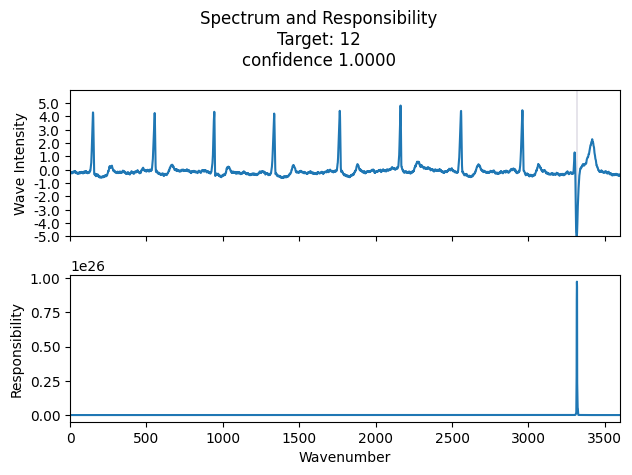

In [20]:
rex.show()